# Agua desde guijarros secos e hidrógeno

**Una roca volcánica secada a fondo, un chorro de hidrógeno caliente y 15 minutos. Resultado: hasta 24,7 mg de agua por cada gramo de roca.** ¿De dónde sale esa agua?

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Garai et al. (2026). *Experimental simulation of water formation on Earth from dry pebble rain*. **Nature Geoscience**.
**DOI:** [10.1038/s41561-026-02118-7](https://doi.org/10.1038/s41561-026-02118-7)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-24-agua-desde-guijarros-secos-e-hidrogeno/notebook.ipynb)

**Video:** Pendiente

## ¿Qué midieron?

Una idea sobre cómo se armó la Tierra: creció atrapando granos de roca de milímetros a centímetros —guijarros (*pebbles*)— que caían a través de una atmósfera primitiva caliente y rica en hidrógeno. ¿Qué le pasa a un guijarro así?

El equipo lo simuló en el laboratorio: fundieron basalto sin agua —MORB (el basalto de las dorsales oceánicas) y picrobasalto (uno mucho más rico en magnesio)— en una corriente de H₂. La roca fundida queda como un vidrio; tras el H₂, ese vidrio («el silicato») convive con gotas de hierro metálico. La química en juego: el hidrógeno le quita el oxígeno al óxido de hierro (FeO), queda hierro metálico y sale vapor de agua (FeO + H₂ → Fe + H₂O).

Ojo con una cosa: la roca natural no es seca de fábrica. Primero la desgasificaron en helio (He) y solo después entró el H₂. Usaron dos hornos: uno resistivo (1.200 o 1.300 °C, 60 o 180 min) y uno de inducción (15 min, entre 1.200 y 1.450 °C sin control fino). Para saber cuánto hierro se fue, leyeron la roca punto por punto con una microsonda electrónica: un haz de electrones que dice qué elementos hay en un punto diminuto.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TEMP_ALTA = 1300             # °C del horno resistivo que se compara en el histograma (1200 o 1300)
ESTADISTICO = 'mean'         # 'mean' (como el paper) o 'median' para la eficiencia por microsonda
FUENTE = 'Fuente: Garai et al. (2026), Nature Geoscience | Datos: Tablas S1–S3 del material suplementario (MOESM2)'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'
COLOR_SECUNDARIO = '#059669'
COLOR_VIOLETA = '#7C3AED'
COLOR_CONTEXTO = '#BBBBBB'

import os, re, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-09-24-agua-desde-guijarros-secos-e-hidrogeno'
ARCHIVOS = ['experimentos_tabla_s1.csv', 'microsonda_tabla_s2_largo.csv',
            'microsonda_resumen_por_fase.csv', 'eficiencia_reduccion.csv',
            'isotopos_dD_tabla_s3.csv']
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
for a in ARCHIVOS:
    if not os.path.exists(f'datos/{a}'):
        urllib.request.urlretrieve(f'{BASE}/datos/{a}', f'datos/{a}')

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# Números en formato español: coma decimal, punto de miles
def es(x):
    s = str(x)
    s = re.sub(r'(?<=\d)\.(?=\d)', ',', s)
    s = re.sub(r'(\d)e\+?(-?)0*(\d+)', r'\1×10^\2\3', s)
    return s.replace('_', '.')

def pr(*a):
    print(*[es(x) for x in a])

exp = pd.read_csv('datos/experimentos_tabla_s1.csv')       # Tabla S1: masas y agua por experimento
ems = pd.read_csv('datos/microsonda_tabla_s2_largo.csv')   # Tabla S2: cada punto de microsonda
res = pd.read_csv('datos/microsonda_resumen_por_fase.csv') # Tabla S2 resumida por bloque y fase
efi = pd.read_csv('datos/eficiencia_reduccion.csv')        # eficiencia por experimento (extract)
iso = pd.read_csv('datos/isotopos_dD_tabla_s3.csv')        # Tabla S3: deuterio del agua

FEO_POR_FE = 71.844 / 55.845    # wt% Fe → wt% FeO
FEO_POR_H2O = 71.844 / 18.015   # 1 mol de agua = 1 mol de FeO reducido (SI §S3)

# --- Recalcular la eficiencia desde cero (no nos fiamos de la columna precalculada) ---
def feo_puntos(fase, t=None, h=None):
    sub = ems[(ems.fase == fase) & (ems.elemento == 'Fe')]
    if t is not None:
        sub = sub[(sub.temperatura_c == t) & (sub.horas == h)]
    return sub.wt_pct * FEO_POR_FE

def eficiencia_erh(t, h, stat=ESTADISTICO):
    ini = getattr(feo_puntos('vidrio_anhidro', t, h), stat)()
    fin = feo_puntos('silicato_tras_H2', t, h)
    return (1 - getattr(fin, stat)() / ini) * 100, fin.std() / ini * 100

CONDICIONES = [(1200, 1), (1200, 3), (1300, 1), (1300, 3)]
erh = pd.DataFrame([(t, h * 60, *eficiencia_erh(t, h)) for t, h in CONDICIONES],
                   columns=['temperatura_c', 'minutos', 'eficiencia', 'sd'])

ih = exp[exp.horno == 'IH'].copy()
feo_ini = {'MORB': feo_puntos('MORB_inicial').mean(), 'Picrobasalt': feo_puntos('picrobasalto_anhidro').mean()}
ih['eficiencia'] = ih.h2_agua_mg * FEO_POR_H2O / (ih.masa_inicial_mg * ih.composicion.map(feo_ini) / 100) * 100
ih['agua_h2_g'] = ih.h2_agua_mg / ih.masa_inicial_mg * 1000   # mg de agua por g de roca
ih['agua_he_g'] = ih.he_agua_mg / ih.masa_inicial_mg * 1000
ih['ratio'] = ih.agua_h2_g / ih.agua_he_g

# Cross-check contra la tabla del extract (con la media, como el paper)
if ESTADISTICO == 'mean':
    assert np.allclose(erh.eficiencia, efi[efi.horno == 'ERH'].eficiencia_pct, atol=0.1)
    assert np.allclose(ih.eficiencia, efi[efi.horno == 'IH'].eficiencia_pct, atol=0.1)

todas = np.concatenate([erh.eficiencia, ih.eficiencia])
q1, q3 = np.percentile(todas, [25, 75])
dD_tanque = iso.dD_permil_vsmow.iloc[0]
dD_agua = iso.dD_permil_vsmow.iloc[1:]

pr(f'Experimentos en la Tabla S1: {len(exp)} · útiles: {len(todas)} (E05 fuera: su balance de masas no cuadra)')
print('\nHorno resistivo (eficiencia por microsonda):')
for _, r in erh.iterrows():
    pr(f'  {r.temperatura_c:_.0f} °C, {r.minutos:.0f} min → {r.eficiencia:.1f} % del FeO reducido (desv. estándar {r.sd:.1f})')
print('\nHorno de inducción, 15 min (eficiencia por agua recogida):')
for _, r in ih.iterrows():
    pr(f'  {r.exp_id} {r.composicion.replace("Picrobasalt", "Picrobasalto"):<12} {r.masa_inicial_mg/1000:.1f} g → {r.eficiencia:.1f} % · '
       f'{r.h2_agua_mg:.1f} mg de agua ({r.agua_h2_g:.1f} mg/g)')
pr(f'\nLas {len(todas)}: mediana {np.median(todas):.1f} %, IQR {q1:.1f}–{q3:.1f} %, rango {todas.min():.1f}–{todas.max():.1f} %')
pr((f'Deuterio: agua {dD_agua.max():.1f} a {dD_agua.min():.1f} ‰ frente a {dD_tanque:.1f} ‰ del H₂ del tanque '
    f'(+{(dD_agua - dD_tanque).min():.1f} a +{(dD_agua - dD_tanque).max():.1f} ‰)').replace('-', '−'))

Experimentos en la Tabla S1: 11 · útiles: 10 (E05 fuera: su balance de masas no cuadra)

Horno resistivo (eficiencia por microsonda):
  1.200 °C, 60 min → 20,3 % del FeO reducido (desv. estándar 13,6)
  1.200 °C, 180 min → 22,7 % del FeO reducido (desv. estándar 21,2)
  1.300 °C, 60 min → 67,4 % del FeO reducido (desv. estándar 18,3)
  1.300 °C, 180 min → 69,7 % del FeO reducido (desv. estándar 12,0)

Horno de inducción, 15 min (eficiencia por agua recogida):
  E06 MORB         0,5 g → 51,2 % · 8,2 mg de agua (16,4 mg/g)
  E07 MORB         0,8 g → 77,1 % · 19,8 mg de agua (24,7 mg/g)
  E08 MORB         1,0 g → 63,4 % · 20,3 mg de agua (20,3 mg/g)
  E09 Picrobasalto 0,5 g → 20,8 % · 3,0 mg de agua (6,0 mg/g)
  E10 Picrobasalto 0,8 g → 65,4 % · 15,1 mg de agua (18,9 mg/g)
  E11 Picrobasalto 1,0 g → 43,3 % · 12,5 mg de agua (12,5 mg/g)

Las 10: mediana 57,3 %, IQR 27,9–66,9 %, rango 20,3–77,1 %
Deuterio: agua −50,0 a −76,0 ‰ frente a −149,8 ‰ del H₂ del tanque (+73,8 a +99,8 ‰)


Aquí está.

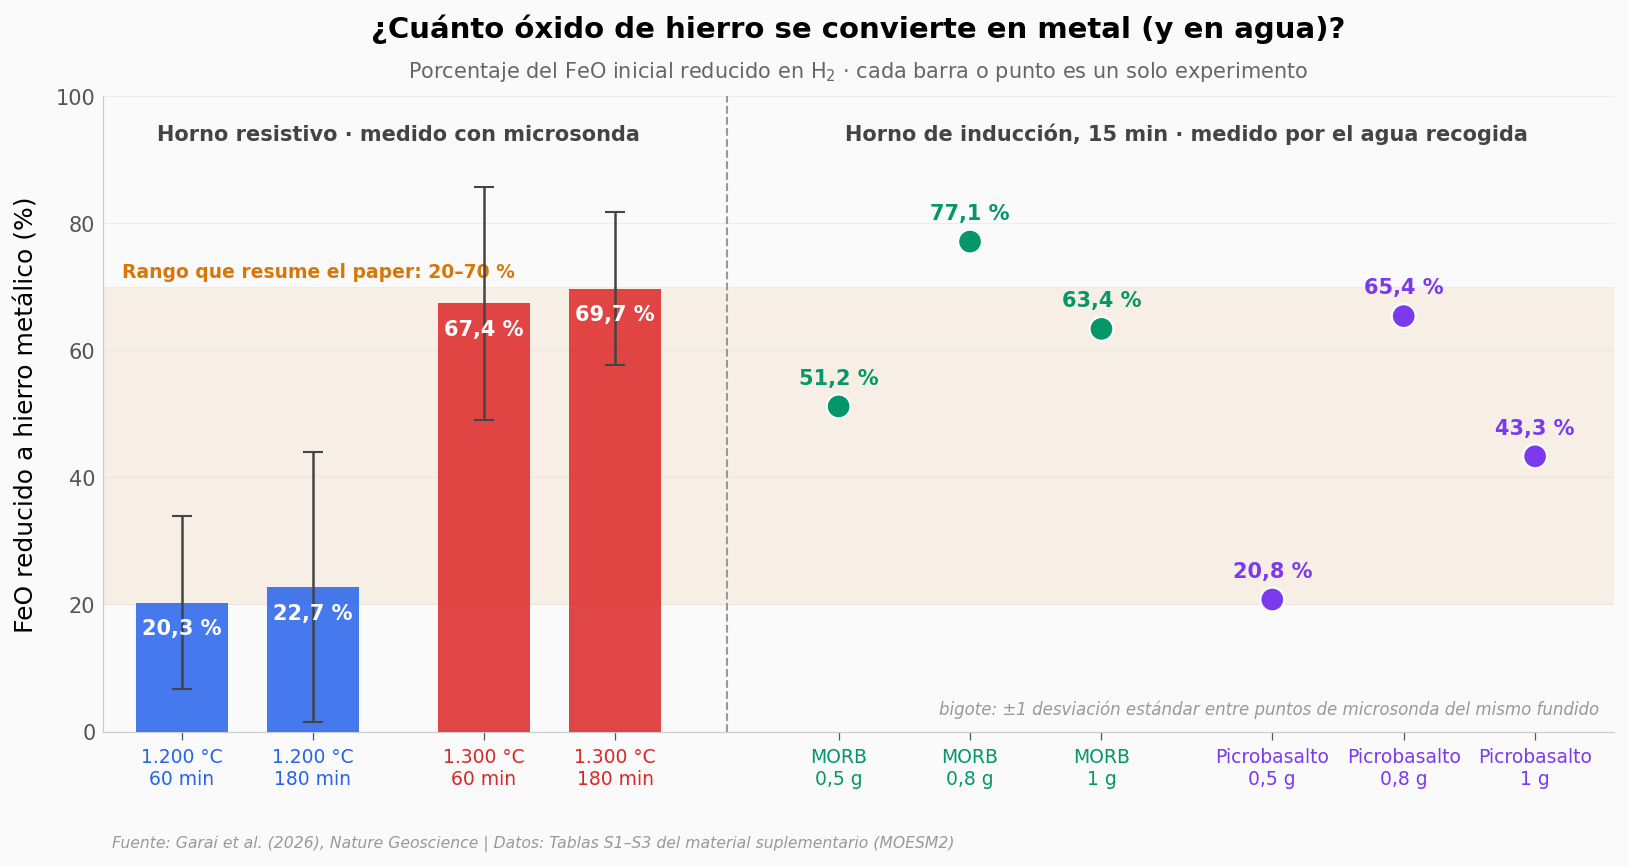

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))
pos_erh = [0, 1, 2.3, 3.3]
pos_ih = [5, 6, 7, 8.3, 9.3, 10.3]

ax.axhspan(20, 70, color=COLOR_REFERENCIA, alpha=0.08, zorder=0)
ax.text(-0.45, 71.5, 'Rango que resume el paper: 20–70 %', color=COLOR_REFERENCIA,
        fontsize=9, fontweight='bold', ha='left')

# Horno resistivo: barra = un experimento; bigote = dispersión entre puntos de microsonda
cols_erh = [COLOR_DATOS if t == 1200 else COLOR_ALERTA for t in erh.temperatura_c]
ax.bar(pos_erh, erh.eficiencia, width=0.7, color=cols_erh, alpha=0.85, zorder=3)
ax.errorbar(pos_erh, erh.eficiencia, yerr=erh.sd, fmt='none', ecolor='#444444',
            capsize=5, lw=1.2, zorder=4)
for x, v in zip(pos_erh, erh.eficiencia):
    ax.text(x, v - 2.5, es(f'{v:.1f} %'), ha='center', va='top', fontsize=10,
            color='white', fontweight='bold', zorder=5)

# Horno de inducción: un punto por experimento
cols_ih = [COLOR_SECUNDARIO if c == 'MORB' else COLOR_VIOLETA for c in ih.composicion]
ax.scatter(pos_ih, ih.eficiencia, s=130, color=cols_ih, edgecolors='white', linewidths=1, zorder=5)
for x, v, c in zip(pos_ih, ih.eficiencia, cols_ih):
    ax.text(x, v + 3.5, es(f'{v:.1f} %'), ha='center', fontsize=10, color=c, fontweight='bold')

ax.axvline(4.15, color='#999999', lw=1, ls='--')
ax.text(1.65, 93, 'Horno resistivo · medido con microsonda', ha='center', fontsize=10, color='#444444', fontweight='bold')
ax.text(7.65, 93, 'Horno de inducción, 15 min · medido por el agua recogida', ha='center',
        fontsize=10, color='#444444', fontweight='bold')

etiquetas = [f'{es(f"{t:_}")} °C\n{m} min' for t, m in zip(erh.temperatura_c, erh.minutos)]
nombre = {'MORB': 'MORB', 'Picrobasalt': 'Picrobasalto'}
etiquetas += [f'{nombre[c]}\n{es(f"{m/1000:.1f}".rstrip("0").rstrip("."))} g'
              for c, m in zip(ih.composicion, ih.masa_inicial_mg)]
ax.set_xticks(pos_erh + pos_ih)
ax.set_xticklabels(etiquetas, fontsize=9)
for tick, c in zip(ax.get_xticklabels(), cols_erh + cols_ih):
    tick.set_color(c)
ax.set_ylim(0, 100)
ax.set_xlim(-0.6, 10.9)
ax.set_ylabel('FeO reducido a hierro metálico (%)')
ax.set_title('¿Cuánto óxido de hierro se convierte en metal (y en agua)?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Porcentaje del FeO inicial reducido en H$_2$ · cada barra o punto es un solo experimento',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.99, 0.02, 'bigote: ±1 desviación estándar entre puntos de microsonda del mismo fundido',
        transform=ax.transAxes, fontsize=8, color='#999999', ha='right', va='bottom', style='italic')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/eficiencia_reduccion.png', dpi=200, bbox_inches='tight')
plt.show()

La temperatura manda. En el horno resistivo, pasar de 1.200 a 1.300 °C triplica, más o menos, la fracción de FeO reducido (de 20,3 a 67,4 % en una hora). Dejarlo tres horas en vez de una suma apenas 2,3–2,4 puntos.

En el horno de inducción, 15 minutos bastaron para reducir entre 20,8 y 77,1 %, aunque ahí la temperatura osciló sin control fino y la dispersión es grande. Si juntamos las 10 eficiencias sale una mediana de 57,3 % (la mitad central va de 27,9 a 66,9 %; IQR), pero no es una distribución de verdad: mezcla dos hornos que miden la eficiencia de forma distinta, y en el de inducción no sabemos la temperatura exacta de cada experimento.

Un detalle: el paper resume «20–70 %». Nuestro recálculo cuadra en el horno resistivo, pero E07 (MORB, 0,8 g) llega a 77,1 %. Y lo más importante: cada condición es **un solo experimento**. Sin réplicas, esto describe; no pone a prueba nada.

## ¿Y el agua?

En el horno de inducción el agua la recogieron en una trampa, así que ahí sí está medida. Y hay un truco: antes del H₂, cada muestra pasó 15 minutos en helio. Comparemos las dos etapas.

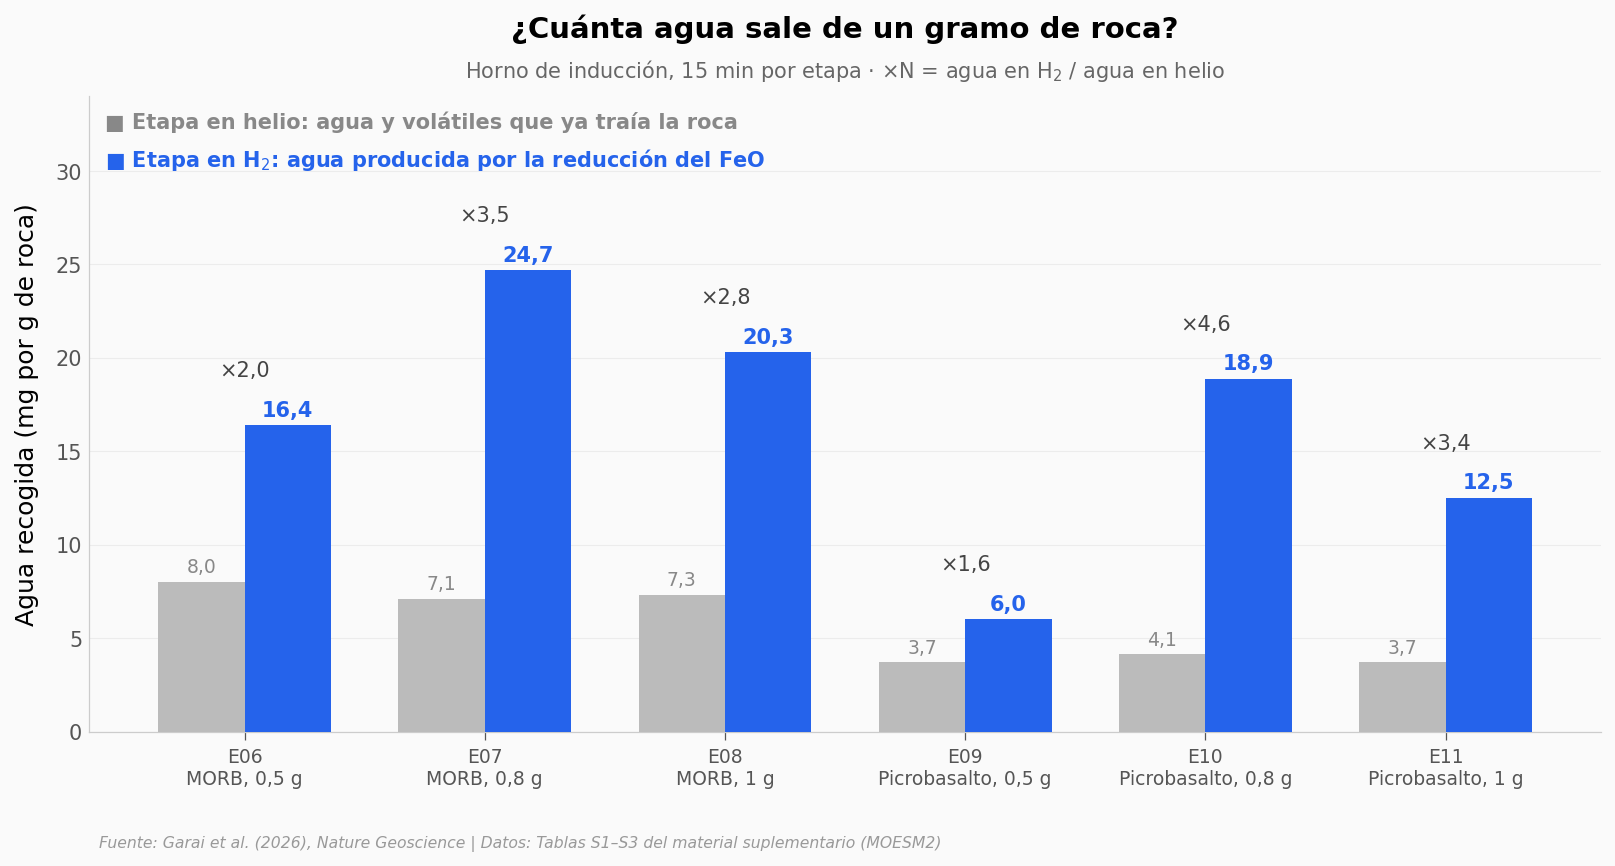

Etapa en helio: 3,7–8,0 mg/g · etapa en H₂: 6,0–24,7 mg/g (mediana 17,6; IQR 13,5–19,9) · H₂/helio: 1,6–4,6×


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(ih))
w = 0.36
ax.bar(x - w/2, ih.agua_he_g, w, color=COLOR_CONTEXTO, zorder=3)
ax.bar(x + w/2, ih.agua_h2_g, w, color=COLOR_DATOS, zorder=3)
for xi, he, h2, ra in zip(x, ih.agua_he_g, ih.agua_h2_g, ih.ratio):
    ax.text(xi + w/2, h2 + 0.5, es(f'{h2:.1f}'), ha='center', fontsize=10, color=COLOR_DATOS, fontweight='bold')
    ax.text(xi - w/2, he + 0.5, es(f'{he:.1f}'), ha='center', fontsize=9, color='#888888')
    ax.text(xi, max(he, h2) + 2.6, es(f'×{ra:.1f}'), ha='center', fontsize=10, color='#444444')

ax.text(0.01, 0.95, '■ Etapa en helio: agua y volátiles que ya traía la roca', transform=ax.transAxes,
        fontsize=10, color='#888888', fontweight='bold')
ax.text(0.01, 0.89, '■ Etapa en H$_2$: agua producida por la reducción del FeO', transform=ax.transAxes,
        fontsize=10, color=COLOR_DATOS, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{e}\n{nombre[c]}, {es(f"{m/1000:.1f}".rstrip("0").rstrip("."))} g'
                    for e, c, m in zip(ih.exp_id, ih.composicion, ih.masa_inicial_mg)], fontsize=9)
ax.set_ylim(0, 34)
ax.set_ylabel('Agua recogida (mg por g de roca)')
ax.set_title('¿Cuánta agua sale de un gramo de roca?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Horno de inducción, 15 min por etapa · ×N = agua en H$_2$ / agua en helio',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/agua_por_gramo.png', dpi=200, bbox_inches='tight')
plt.show()

pr(f'Etapa en helio: {ih.agua_he_g.min():.1f}–{ih.agua_he_g.max():.1f} mg/g · etapa en H₂: '
   f'{ih.agua_h2_g.min():.1f}–{ih.agua_h2_g.max():.1f} mg/g (mediana {ih.agua_h2_g.median():.1f}; '
   f'IQR {ih.agua_h2_g.quantile(.25):.1f}–{ih.agua_h2_g.quantile(.75):.1f}) · '
   f'H₂/helio: {ih.ratio.min():.1f}–{ih.ratio.max():.1f}×')

La etapa en helio ya suelta 3,7–8,0 mg por gramo: agua y otros volátiles que la roca natural traía de antes. El H₂ produce entre 1,6 y 4,6 veces más: de 6,0 a 24,7 mg por gramo (mediana 17,6; IQR 13,5–19,9), o sea 0,6–2,5 % de la masa de la roca. Y la cantidad no crece de forma ordenada con la masa de la muestra.

En el horno resistivo el agua no se midió: los autores la estimaron a partir del FeO perdido (0,80–2,27 mg), por eso no aparece aquí.

Hay otra huella: el agua que sale es más rica en deuterio (hidrógeno pesado) que el gas del que viene. Su δD va de −50 a −76 ‰, frente a −149,8 ‰ del H₂ del tanque: entre 74 y 100 ‰ más pesada.

## ¿Y qué queda en la roca?

El hierro metálico que se forma no se va solo. El abstract dice que el metal «secuestra fuertemente» el fósforo (P). Veamos en qué condiciones.

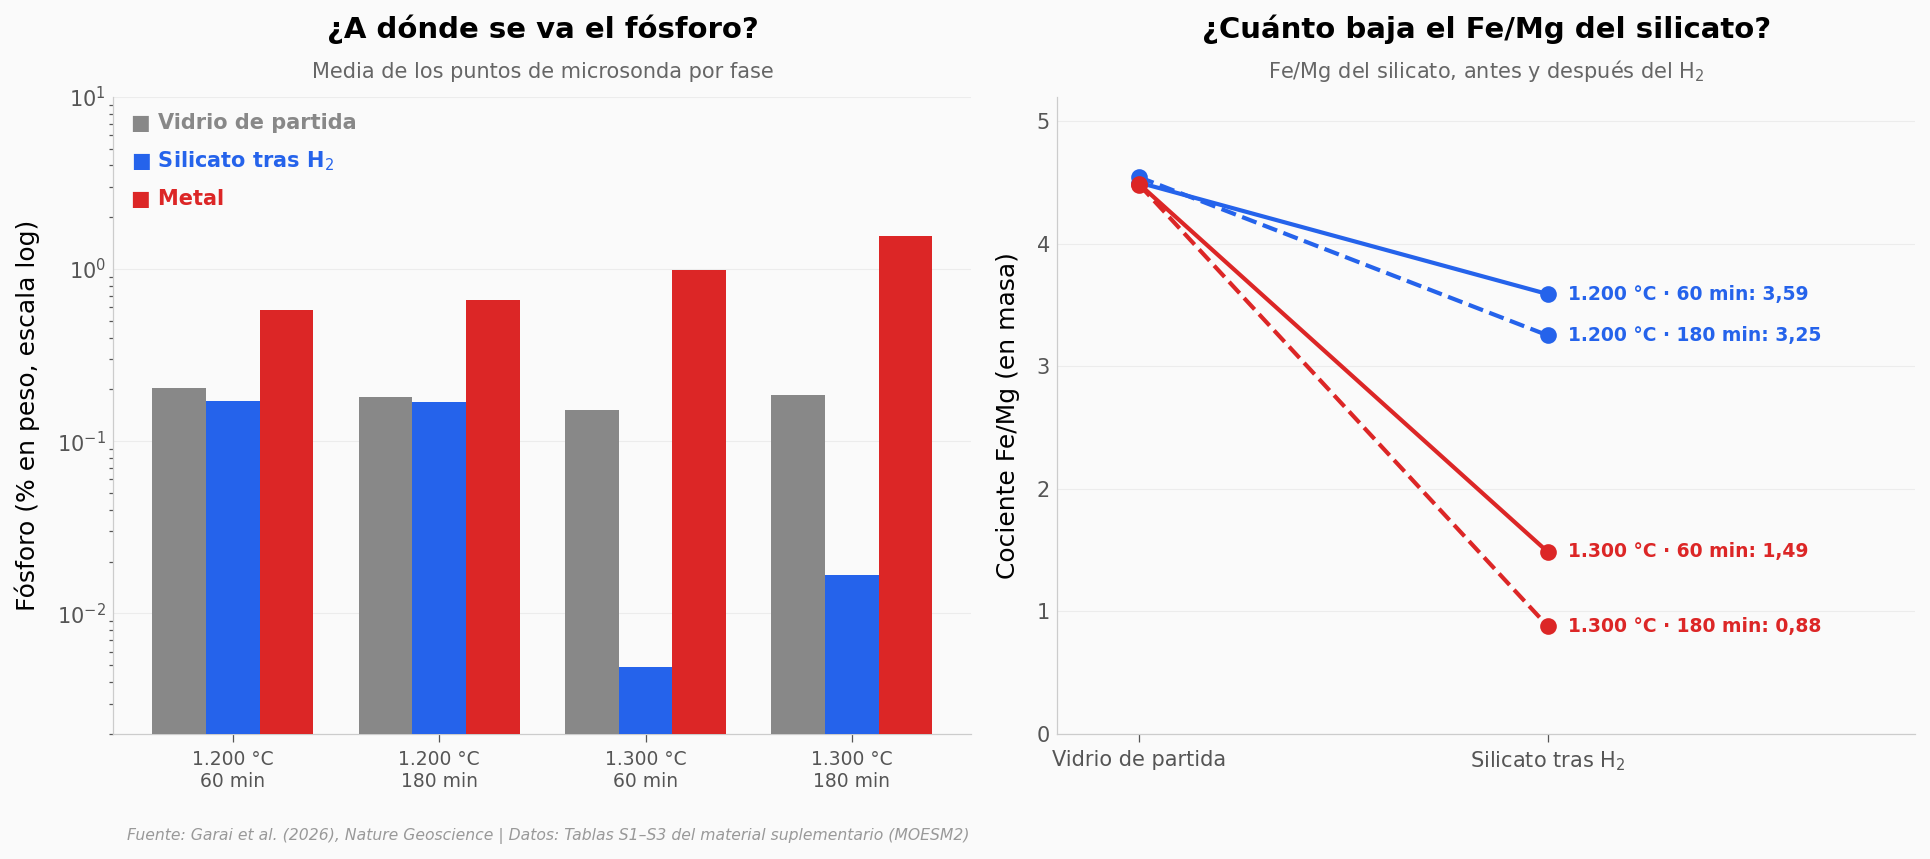

1.200 °C, 60 min: el silicato pierde 15,7 % de su P · P en el metal 0,575 wt%
1.200 °C, 180 min: el silicato pierde 7,1 % de su P · P en el metal 0,659 wt%
1.300 °C, 60 min: el silicato pierde 96,8 % de su P · P en el metal 0,989 wt%
1.300 °C, 180 min: el silicato pierde 91,0 % de su P · P en el metal 1,546 wt%
Máximo de P en un punto de metal: 2,88 wt%


In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.5))
et_cond = [f'{es(f"{t:_}")} °C\n{h*60} min' for t, h in CONDICIONES]

# --- Fósforo por fase (escala logarítmica) ---
def media(t, h, fase, el):
    return res[(res.temperatura_c == t) & (res.horas == h) & (res.fase == fase)][f'{el}_mean'].iloc[0]

x = np.arange(len(CONDICIONES))
w = 0.26
series = [('vidrio_anhidro', 'Vidrio de partida', '#888888'),
          ('silicato_tras_H2', 'Silicato tras H$_2$', COLOR_DATOS),
          ('metal', 'Metal', COLOR_ALERTA)]
for k, (fase, nom, c) in enumerate(series):
    vals = [media(t, h, fase, 'P') for t, h in CONDICIONES]
    a1.bar(x + (k - 1) * w, vals, w, color=c, zorder=3)
    a1.text(0.02, 0.95 - 0.06 * k, f'■ {nom}', transform=a1.transAxes, fontsize=10, color=c, fontweight='bold')
a1.set_yscale('log')
a1.set_ylim(0.002, 10)
a1.set_xticks(x)
a1.set_xticklabels(et_cond, fontsize=9)
a1.set_ylabel('Fósforo (% en peso, escala log)')
a1.set_title('¿A dónde se va el fósforo?', fontsize=14, fontweight='bold', pad=28)
a1.text(0.5, 1.03, 'Media de los puntos de microsonda por fase', transform=a1.transAxes,
        fontsize=10, color='#666666', ha='center')

# --- Fe/Mg del silicato, antes y después ---
for t, h in CONDICIONES:
    antes = media(t, h, 'vidrio_anhidro', 'Fe') / media(t, h, 'vidrio_anhidro', 'Mg')
    despues = media(t, h, 'silicato_tras_H2', 'Fe') / media(t, h, 'silicato_tras_H2', 'Mg')
    c = COLOR_DATOS if t == 1200 else COLOR_ALERTA
    ls = '-' if h == 1 else '--'
    a2.plot([0, 1], [antes, despues], color=c, ls=ls, lw=2, marker='o', ms=7, zorder=4)
    a2.text(1.05, despues, es(f'{t:_} °C · {h*60} min: {despues:.2f}'), color=c, fontsize=9,
            va='center', fontweight='bold')
a2.set_xlim(-0.2, 1.9)
a2.set_ylim(0, 5.2)
a2.set_xticks([0, 1])
a2.set_xticklabels(['Vidrio de partida', 'Silicato tras H$_2$'], fontsize=10)
a2.set_ylabel('Cociente Fe/Mg (en masa)')
a2.set_title('¿Cuánto baja el Fe/Mg del silicato?', fontsize=14, fontweight='bold', pad=28)
a2.text(0.5, 1.03, 'Fe/Mg del silicato, antes y después del H$_2$', transform=a2.transAxes,
        fontsize=10, color='#666666', ha='center')
plt.tight_layout()
fig.text(0.07, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/fosforo_y_fe_mg.png', dpi=200, bbox_inches='tight')
plt.show()

for t, h in CONDICIONES:
    p0, p1 = media(t, h, 'vidrio_anhidro', 'P'), media(t, h, 'silicato_tras_H2', 'P')
    pr(f'{t:_} °C, {h*60} min: el silicato pierde {(1 - p1/p0)*100:.1f} % de su P · P en el metal {media(t, h, "metal", "P"):.3f} wt%')
pmax = ems[(ems.fase == 'metal') & (ems.elemento == 'P')].wt_pct.max()
pr(f'Máximo de P en un punto de metal: {pmax:.2f} wt%')

A 1.300 °C, el silicato pierde el 91–97 % de su fósforo, que termina en el metal (hasta 2,88 % en peso de P —el «wt%» de las tablas—, partiendo de ~0,15–0,20 wt% en el vidrio). A 1.200 °C la pérdida es de apenas 7–16 %: el secuestro es fuerte solo en caliente. Y como se va el hierro, el cociente Fe/Mg del silicato cae: de ~4,5 a 1,49 en una hora a 1.300 °C, con el magnesio casi quieto (2,30 → 2,26 wt%). Tras 3 h llega a 0,88, pero ahí el magnesio medido también sube (2,26 → 3,49 wt%), así que no todo es hierro perdido.

La propuesta de los autores: si ese metal se hundió hasta el núcleo, podría explicar por qué el manto terrestre tiene poco fósforo comparado con el de Marte, y un Fe/Mg bajo. Es una hipótesis: estos datos no la prueban. (El metal también trae tungsteno, W, pero viene del portador de la muestra: es contaminación, no parte del fenómeno).

## ¿Qué tan profundo es el cambio?

Miremos cada análisis de microsonda, no las medias.

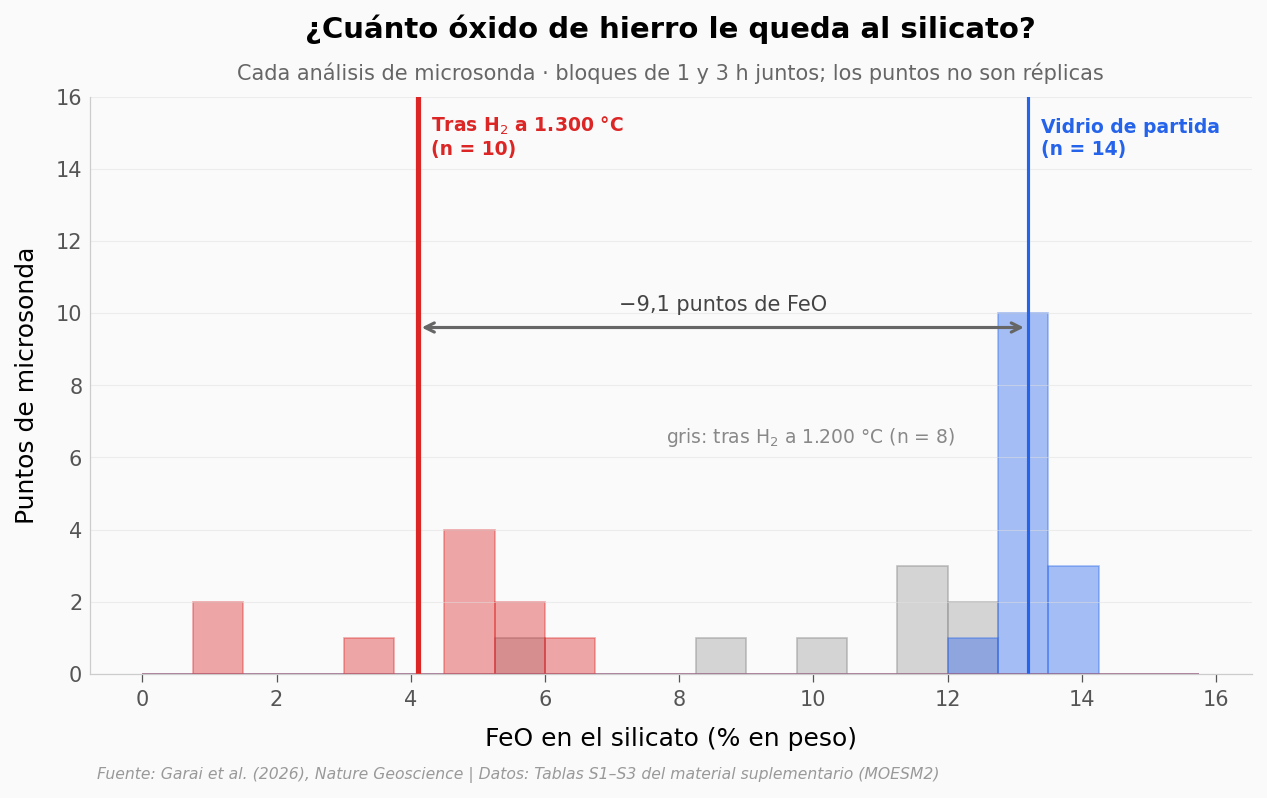

FeO del vidrio de partida: media 13,20 wt% (n = 14)
FeO tras H₂ a 1.300 °C: media 4,10 wt% (n = 10), mínimo 0,80 · a 1.200 °C: media 10,35 wt%


In [5]:
pts = ems[ems.elemento == 'Fe'].copy()
pts['FeO'] = pts.wt_pct * FEO_POR_FE
otra = 1200 if TEMP_ALTA == 1300 else 1300
antes = pts[pts.fase == 'vidrio_anhidro'].FeO
despues = pts[(pts.fase == 'silicato_tras_H2') & (pts.temperatura_c == TEMP_ALTA)].FeO
contexto = pts[(pts.fase == 'silicato_tras_H2') & (pts.temperatura_c == otra)].FeO

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.arange(0, 16.5, 0.75)
ax.hist(contexto, bins=bins, color=COLOR_CONTEXTO, alpha=0.6, edgecolor='#999999', linewidth=0.8)
ax.hist(antes, bins=bins, color=COLOR_DATOS, alpha=0.4, edgecolor=COLOR_DATOS, linewidth=0.8)
n, _, _ = ax.hist(despues, bins=bins, color=COLOR_ALERTA, alpha=0.4, edgecolor=COLOR_ALERTA, linewidth=0.8)
y_max = max(np.histogram(antes, bins)[0].max(), n.max()) * 1.6
ax.set_ylim(0, y_max)
ax.axvline(antes.mean(), color=COLOR_DATOS, linewidth=1.5)
ax.axvline(despues.mean(), color=COLOR_ALERTA, linewidth=2.5)
ax.annotate('', xy=(despues.mean(), y_max * 0.6), xytext=(antes.mean(), y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((antes.mean() + despues.mean()) / 2, y_max * 0.63,
        es(f'−{antes.mean() - despues.mean():.1f} puntos de FeO'), ha='center', fontsize=10, color='#444444')
ax.text(antes.mean() + 0.2, y_max * 0.9, es(f'Vidrio de partida\n(n = {len(antes)})'),
        color=COLOR_DATOS, fontsize=9, fontweight='bold')
ax.text(despues.mean() + 0.2, y_max * 0.9, 'Tras H$_2$ a ' + es(f'{TEMP_ALTA:_} °C\n(n = {len(despues)})'),
        color=COLOR_ALERTA, fontsize=9, fontweight='bold')
ax.text(0.62, 0.40, 'gris: tras H$_2$ a ' + es(f'{otra:_} °C (n = {len(contexto)})'), transform=ax.transAxes,
        color='#888888', fontsize=9, ha='center')
ax.set_xlabel('FeO en el silicato (% en peso)')
ax.set_ylabel('Puntos de microsonda')
ax.set_title('¿Cuánto óxido de hierro le queda al silicato?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada análisis de microsonda · bloques de 1 y 3 h juntos; los puntos no son réplicas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_feo.png', dpi=200, bbox_inches='tight')
plt.show()

pr(f'FeO del vidrio de partida: media {antes.mean():.2f} wt% (n = {len(antes)})')
pr(f'FeO tras H₂ a {TEMP_ALTA:_} °C: media {despues.mean():.2f} wt% (n = {len(despues)}), '
   f'mínimo {despues.min():.2f} · a {otra:_} °C: media {contexto.mean():.2f} wt%')

A 1.300 °C al silicato le queda menos de un tercio del FeO del vidrio de partida: en promedio, de 13,20 a 4,10 wt% (bloques de 1 y 3 horas juntos, como en la gráfica); en el experimento de 3 horas, de 13,05 a 3,95 wt%. A 1.200 °C los puntos bajan mucho menos (media 10,35 wt%, entre 5,44 y 12,49), aunque ninguno queda dentro del rango del vidrio original (12,54–13,69 wt%). En los dos bloques calientes hay un punto muy empobrecido (0,62 y 0,91 wt% de Fe; el mínimo del histograma, 0,80 wt%, está en FeO); la media lo incluye, igual que el paper. Con la mediana, la eficiencia baja entre 5 y 9 puntos (a 1.200 °C, 3 h, de 22,7 a 13,4 %), aunque 1.300 °C sigue muy por encima: lo puedes probar abajo.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Fundir basalto sin agua en H₂ produjo agua en los 6 experimentos del horno de inducción | ✅ | 3,0–20,3 mg por muestra de 0,5–1 g; 6,0–24,7 mg por gramo, entre 1,6 y 4,6 veces lo que soltó la etapa en helio |
| A 1.300 °C se reduce el 67–70 % del FeO y a 1.200 °C, el 20–23 % | ✅ | Horno resistivo, recalculado desde la microsonda; un experimento por condición, sin réplicas |
| El rango de 20–70 % que resume el paper cuadra con nuestro recálculo | ⚠️ | Sí en el horno resistivo (20,3–69,7 %); en el de inducción E07 llega a 77,1 % |
| El metal se queda con el fósforo del silicato | ⚠️ | Fuerte a 1.300 °C (el silicato pierde el 91–97 %); débil a 1.200 °C (7–16 %) |
| El cociente Fe/Mg del silicato baja | ✅ | De ~4,5 a 1,49 a 1.300 °C en 1 h (Mg casi quieto) y a 0,88 tras 3 h, donde el Mg medido además sube de 2,3 a 3,5 wt% |
| El agua producida es más rica en deuterio que el H₂ de partida | ✅ | δD de −50 a −76 ‰ frente a −149,8 ‰ del tanque (+74 a +100 ‰) |
| El agua del horno resistivo está medida | ❌ | Es una estimación de los autores desde el FeO perdido (0,80–2,27 mg); nuestro recálculo cuadra (hasta 13 % de diferencia), pero no es evidencia independiente |
| Estos experimentos muestran océanos de agua en la Tierra | ❌ | El laboratorio produce miligramos; la escala de océanos sale de un modelo del paper que no se puede reproducir con estos datos |

> **Limitaciones:** un solo experimento por condición, así que no hay réplicas ni tests estadísticos; los puntos de microsonda son del mismo fundido. Los dos hornos miden la eficiencia de forma distinta (microsonda vs agua recogida). La temperatura del horno de inducción no está controlada con precisión. El tungsteno del metal es contaminación del portador. E05 queda fuera porque su balance de masas no cuadra. Que la Tierra haya ganado agua así, o que exoplanetas hechos de guijarros *puedan* heredar océanos de este modo, son propuestas de los autores, no resultados de estos datos.

## Ahora tú

1. **¿Cambia la historia si usas la mediana en vez de la media?** La celda de abajo ya lo hace: compara las dos columnas.
2. **¿Qué pasa en el bloque de 1.200 °C, punto a punto?** Cambia `TEMP_ALTA = 1200` en la configuración y vuelve a correr el histograma.
3. **¿El agua por gramo depende de la masa de la muestra?** Prueba `ih.plot.scatter('masa_inicial_mg', 'agua_h2_g')` y separa MORB de picrobasalto.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Eficiencia del horno resistivo con la media (como el paper) y con la mediana
comp = pd.DataFrame([(t, h * 60, eficiencia_erh(t, h, 'mean')[0], eficiencia_erh(t, h, 'median')[0])
                     for t, h in CONDICIONES],
                    columns=['°C', 'min', 'Con media (%)', 'Con mediana (%)'])
comp['Diferencia (puntos)'] = comp['Con mediana (%)'] - comp['Con media (%)']
comp = comp.round(1)
comp['°C'] = [f'{t:_}' for t in comp['°C']]
pr(comp.to_string(index=False).replace('-', '−'))

   °C  min  Con media (%)  Con mediana (%)  Diferencia (puntos)
1.200   60           20,3             14,5                 −5,8
1.200  180           22,7             13,4                 −9,3
1.300   60           67,4             60,8                 −6,6
1.300  180           69,7             64,6                 −5,1


## Créditos

- **Paper:** Garai, Sharp, Olson & Gargano (2026). *Experimental simulation of water formation on Earth from dry pebble rain*. Nature Geoscience. [DOI: 10.1038/s41561-026-02118-7](https://doi.org/10.1038/s41561-026-02118-7)
- **Datos:** Tablas S1–S3 del material suplementario del paper (MOESM2) y fórmula de eficiencia del SI §S3 (MOESM1). El depósito en Dryad ([10.5061/dryad.fttdz0980](https://doi.org/10.5061/dryad.fttdz0980)) aún no está publicado.
- **Notebook:** [Ciencia a Mordiscos · El Lab](https://github.com/Ciencia-a-Mordiscos/lab) — código bajo licencia del repositorio.

## Fuentes

**Paper**: [Experimental simulation of water formation on Earth from dry pebble rain](https://doi.org/10.1038/s41561-026-02118-7)  
*Nature Geoscience, 2026-09-24 · paywall*

**Supplementary Material**: [Supplementary Tables 1–4 for "Experimental simulation of water formation on Earth from dry pebble rain" (MOESM2)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41561-026-02118-7/MediaObjects/41561_2026_2118_MOESM2_ESM.xlsx)  
*Nature Geoscience, 2026-09-24*

**Supplementary Material**: [Supplementary Information for "Experimental simulation of water formation on Earth from dry pebble rain" (MOESM1: Figs. S1–S3, secciones S1–S3)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41561-026-02118-7/MediaObjects/41561_2026_2118_MOESM1_ESM.pdf)  
*Nature Geoscience, 2026-09-24*

**Referencias citadas**: [Experimental simulation of water formation on Earth from dry pebble rain (Garai, Sharp, Olson & Gargano)](https://doi.org/10.5061/dryad.fttdz0980) (Dryad, pendiente de publicación)

*22 afirmaciones del notebook verificadas contra estas fuentes*